
# Analyse des Data Centers aux États-Unis et de leur impact economique, environnemental et sanitaire — 

## Projet Data Analyst - Hugues GOUTTEBROZE - 2026

## Problématique

1. **Où sont concentrés les data centers aux États-Unis et quels États concentrent le plus de sites ?**

Ce notebook construit automatiquement une analyse géographique à partir d'un **dataset réel** issu du PNNL IM3 Open Source Data Center Atlas, via une copie CSV publique publiée par Energy Factbook.

2. **Analyse de l'impact de la forte consommation énergétique des Data Centers au niveau economique, environnemental et sanitaire aux États-Unis**: 

    2.1. **Quels sont les consécquences de la forte consommation d'éléctricité et d'eau au niveau economique, environnemental et sanitaire?** 
    
    2.2 **La consommation énergétique de Data Centers a-t-elle un impact sur les ressources des zones en situation de stress hydrique (région désertiques)?**

### Pipeline

```text
Dataset réel
    ↓
Pandas
    ↓
Nettoyage / contrôle qualité
    ↓
GeoPandas
    ↓
États américains + points des data centers
    ↓
Contextily
    ↓
Carte statique
    ↓
Plotly
    ↓
Carte interactive
    ↓
Graphiques
    ↓
Conclusions métier
```

### Librairies

- **Pandas** : préparation et analyse des données
- **GeoPandas** : données spatiales
- **Matplotlib** : graphiques et carte statique
- **Contextily** : fond de carte
- **Plotly** : carte interactive

> **Important :** le dataset PNNL/IM3 est une compilation ouverte issue notamment d'OpenStreetMap. Il ne constitue pas un recensement exhaustif de tous les data centers américains. La version utilisée ici est datée du 12 février 2026.


In [7]:

# Installation — à exécuter une seule fois si nécessaire
# !pip install pandas geopandas matplotlib contextily plotly requests pyogrio



## 1. Imports et configuration


In [6]:

import re
import warnings
# requests is not needed here; pandas.read_csv() handles the remote CSV directly
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import plotly.express as px

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 7)

print("Pandas :", pd.__version__)
print("GeoPandas :", gpd.__version__)


Pandas : 3.0.5
GeoPandas : 1.1.4



## 2. Récupération automatique du dataset réel

La source publique fournit le fichier :

`pnnl_atlas_records.csv`

Le jeu de données contient notamment un identifiant, l'État, le comté, l'opérateur, le nom du site, la surface et les coordonnées.


In [8]:

# DATA_URL = "https://energyfactbook.com/data-centers/data/pnnl_atlas_records.csv"
df_raw = pd.read_csv("./pnnl_atlas_records.csv")

print("Nombre de lignes :", len(df_raw))
print("Nombre de colonnes :", len(df_raw))
display(df_raw.head())
print("\nColonnes :")
print(df_raw.columns.tolist())


Nombre de lignes : 1237
Nombre de colonnes : 1237


,id,layer,state,state_abb,county,operator,name,sqft,lat,lon
0,2744301,building,New Jersey,NJ,Middlesex County,NaN,Verizon,105786,40.54426,-74.49652
1,14930068,building,New Mexico,NM,Bernalillo County,Sandia National Laboratories,HPC,158463,35.04994,-106.54282
2,15884451,building,New Jersey,NJ,Union County,Barclays,Barclays Datacenter,94373,40.64375,-74.28548
3,16282459,building,Maryland,MD,Anne Arundel County,AiNET,CyberNAP Glen Burnie,89879,39.14024,-76.60643
4,19390019,building,North Dakota,ND,Cass County,NaN,Dakota Carrier Network,25931,46.81510,-96.84433



Colonnes :
['id', 'layer', 'state', 'state_abb', 'county', 'operator', 'name', 'sqft', 'lat', 'lon']



## 3. Normalisation des noms de colonnes

Les noms peuvent varier légèrement selon la version du fichier. On les normalise afin de rendre le notebook plus robuste.


In [9]:

df = df_raw.copy()

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.strip("_")
)

print(df.columns.tolist())


['id', 'layer', 'state', 'state_abb', 'county', 'operator', 'name', 'sqft', 'lat', 'lon']



## 4. Contrôle qualité

Avant de cartographier les données, on vérifie :

- les doublons ;
- les valeurs manquantes ;
- les États ;
- les coordonnées ;
- les types de données.


In [ ]:

print("Doublons exacts :", df.duplicated().sum())
print("\nValeurs manquantes :")
display(df.isna().sum().sort_values(ascending=False).head(15))

print("\nÉtats présents :", df["state"].nunique() if "state" in df.columns else "colonne state absente")



## 5. Nettoyage des coordonnées

Le dataset PNNL publié par Energy Factbook fournit une colonne `coordinates`.

On rend le parsing suffisamment robuste pour gérer une chaîne comme :

```text
(39.0, -77.0)
```

ou

```text
39.0, -77.0
```

Si le fichier contient déjà des colonnes latitude/longitude, elles sont utilisées directement.


In [10]:

def extract_coordinates(df):
    result = df.copy()

    # Recherche de colonnes latitude / longitude existantes
    lat_candidates = [c for c in result.columns if c in ["latitude", "lat", "y"]]
    lon_candidates = [c for c in result.columns if c in ["longitude", "lon", "lng", "x"]]

    if lat_candidates and lon_candidates:
        result["latitude"] = pd.to_numeric(result[lat_candidates[0]], errors="coerce")
        result["longitude"] = pd.to_numeric(result[lon_candidates[0]], errors="coerce")
        return result

    # Sinon, extraction depuis une colonne coordinates
    coord_candidates = [c for c in result.columns if "coordinate" in c or c == "coords"]

    if not coord_candidates:
        raise ValueError(
            "Impossible de trouver les coordonnées. "
            "Inspecte df.columns et adapte la fonction."
        )

    coord_col = coord_candidates[0]

    def parse_coord(value):
        if pd.isna(value):
            return pd.Series([np.nan, np.nan])

        nums = re.findall(r"-?\d+(?:\.\d+)?", str(value))

        if len(nums) < 2:
            return pd.Series([np.nan, np.nan])

        return pd.Series([float(nums[0]), float(nums[1])])

    result[["latitude", "longitude"]] = result[coord_col].apply(parse_coord)

    return result


df = extract_coordinates(df)

# Conversion numérique
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

# Contrôle des coordonnées
valid_coords = (
    df["latitude"].between(-90, 90)
    & df["longitude"].between(-180, 180)
)

print("Coordonnées valides :", valid_coords.sum())
print("Coordonnées invalides :", (~valid_coords).sum())

df = df.loc[valid_coords].copy()

display(
    df[["name", "state", "latitude", "longitude"]]
    .head(10)
)


Coordonnées valides : 1237
Coordonnées invalides : 0


,name,state,latitude,longitude
0,Verizon,New Jersey,40.54426,-74.49652
1,HPC,New Mexico,35.04994,-106.54282
2,Barclays Datacenter,New Jersey,40.64375,-74.28548
3,CyberNAP Glen Burnie,Maryland,39.14024,-76.60643
4,Dakota Carrier Network,North Dakota,46.81510,-96.84433
5,Microsoft Data Center 1,Virginia,38.80241,-77.58238
6,Cyxtera Dallas-Fort Worth Data Center,Texas,32.83272,-97.04104
7,Equinix Infomart,Texas,32.80094,-96.81951
8,CoreSite BO1,Massachusetts,42.37671,-71.07976
9,USPO Terminal Annex,California,34.05810,-118.23539



## 6. Construire le GeoDataFrame

Les coordonnées sont initialement en **WGS84 — EPSG:4326**, le système habituel pour latitude/longitude.



In [12]:

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["longitude"],
        df["latitude"]
    ),
    crs="EPSG:4326"
)

print(gdf.crs)
display(gdf.head())


EPSG:4326


,id,layer,state,state_abb,county,operator,name,sqft,lat,lon,latitude,longitude,geometry
0,2744301,building,New Jersey,NJ,Middlesex County,NaN,Verizon,105786,40.54426,-74.49652,40.54426,-74.49652,POINT (-74.49652 40.54426)
1,14930068,building,New Mexico,NM,Bernalillo County,Sandia National Laboratories,HPC,158463,35.04994,-106.54282,35.04994,-106.54282,POINT (-106.54282 35.04994)
2,15884451,building,New Jersey,NJ,Union County,Barclays,Barclays Datacenter,94373,40.64375,-74.28548,40.64375,-74.28548,POINT (-74.28548 40.64375)
3,16282459,building,Maryland,MD,Anne Arundel County,AiNET,CyberNAP Glen Burnie,89879,39.14024,-76.60643,39.14024,-76.60643,POINT (-76.60643 39.14024)
4,19390019,building,North Dakota,ND,Cass County,NaN,Dakota Carrier Network,25931,46.81510,-96.84433,46.81510,-96.84433,POINT (-96.84433 46.8151)



## 7. Agrégation par État

Nous comptons maintenant le nombre de bâtiments de data centers par État.

Attention : il s'agit de **records de bâtiments dans l'atlas**, et non d'un recensement officiel exhaustif.


In [13]:

state_counts = (
    gdf.groupby("state")
       .size()
       .reset_index(name="data_center_count")
       .sort_values("data_center_count", ascending=False)
)

state_counts["share_pct"] = (
    state_counts["data_center_count"]
    / state_counts["data_center_count"].sum()
    * 100
)

state_counts["cumulative_pct"] = state_counts["share_pct"].cumsum()

display(state_counts.head(15))


,state,data_center_count,share_pct,cumulative_pct
40,Virginia,281,22.716249,22.716249
38,Texas,113,9.135004,31.851253
32,Oregon,100,8.084074,39.935327
3,California,97,7.841552,47.776880
30,Ohio,81,6.548100,54.324980
41,Washington,71,5.739693,60.064673
11,Iowa,58,4.688763,64.753436
25,New Jersey,46,3.718674,68.472110
9,Illinois,42,3.395311,71.867421
1,Arizona,42,3.395311,75.262732



## 8. Graphique — Top 15 des États

Ce graphique répond à une première question métier :

> **Quels États concentrent le plus de data centers dans le dataset ?**


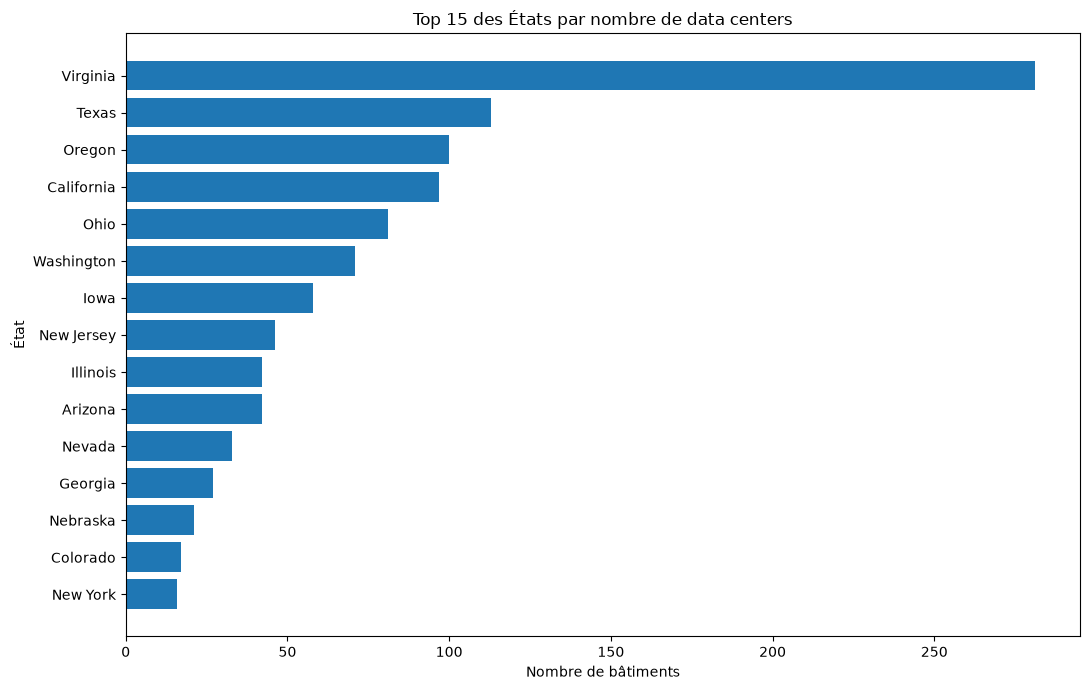

In [14]:

top15 = state_counts.head(15).sort_values("data_center_count")

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    top15["state"],
    top15["data_center_count"]
)

ax.set_title("Top 15 des États par nombre de data centers")
ax.set_xlabel("Nombre de bâtiments")
ax.set_ylabel("État")

plt.tight_layout()
plt.show()



## 9. Analyse de concentration

On calcule la part cumulée des États.

Cela permet de répondre à :

> **Combien d'États représentent 50 % des data centers observés ?**


In [15]:

states_for_50 = state_counts[
    state_counts["cumulative_pct"] <= 50
]

# On ajoute le premier État qui fait dépasser 50 %
first_over_50 = state_counts[
    state_counts["cumulative_pct"] > 50
].head(1)

states_50 = pd.concat(
    [states_for_50, first_over_50]
).drop_duplicates()

print(
    "Nombre d'États nécessaires pour atteindre au moins 50 % :",
    len(states_50)
)

display(states_50)


Nombre d'États nécessaires pour atteindre au moins 50 % : 5


,state,data_center_count,share_pct,cumulative_pct
40,Virginia,281,22.716249,22.716249
38,Texas,113,9.135004,31.851253
32,Oregon,100,8.084074,39.935327
3,California,97,7.841552,47.776880
30,Ohio,81,6.548100,54.324980



## 10. Charger les frontières des États américains

On utilise les **Cartographic Boundary Files** du U.S. Census Bureau.

La carte sert à créer une choroplèthe du nombre de data centers par État.


In [16]:

STATES_URL = (
    "https://www2.census.gov/geo/tiger/GENZ2024/shp/"
    "cb_2024_us_state_500k.zip"
)

states = gpd.read_file(STATES_URL)

print(states.columns.tolist())
display(states.head())


['STATEFP', 'STATENS', 'GEOIDFQ', 'GEOID', 'STUSPS', 'NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry']


,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,35,00897535,0400000US35,35,NM,New Mexico,00,314198519809,726531289,"POLYGON ((-109.05017 31.48, -109.04984 31.4995..."
1,46,01785534,0400000US46,46,SD,South Dakota,00,196341670967,3387563375,"POLYGON ((-104.05788 44.9976, -104.05078 44.99..."
2,06,01779778,0400000US06,06,CA,California,00,403673433805,20291632828,"MULTIPOLYGON (((-118.60442 33.47855, -118.5987..."
3,21,01779786,0400000US21,21,KY,Kentucky,00,102266755818,2384136185,"MULTIPOLYGON (((-89.40565 36.52816, -89.39868 ..."
4,01,01779775,0400000US01,01,AL,Alabama,00,131185561946,4581813708,"MULTIPOLYGON (((-88.05338 30.50699, -88.05109 ..."



## 11. Préparer la jointure géographique

Les frontières du Census utilisent les codes postaux/abréviations d'États.

On crée une correspondance entre le nom de l'État du dataset data centers et son code USPS.


In [17]:

usps = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT",
    "Delaware": "DE", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME",
    "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI",
    "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO",
    "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND",
    "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA",
    "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD",
    "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT",
    "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY", "District of Columbia": "DC"
}

state_counts["STUSPS"] = state_counts["state"].map(usps)

states["STUSPS"] = states["STUSPS"].astype(str)

states_map = states.merge(
    state_counts,
    on="STUSPS",
    how="left"
)

states_map["data_center_count"] = (
    states_map["data_center_count"]
    .fillna(0)
    .astype(int)
)

# Exclusion des territoires pour la carte continentale
states_map = states_map[
    ~states_map["STUSPS"].isin(
        ["PR", "GU", "VI", "MP", "AS"]
    )
].copy()

display(
    states_map[
        ["NAME", "STUSPS", "data_center_count"]
    ]
    .sort_values("data_center_count", ascending=False)
    .head(15)
)


,NAME,STUSPS,data_center_count
41,Virginia,VA,281
35,Texas,TX,113
38,Oregon,OR,100
2,California,CA,97
36,Ohio,OH,81
33,Washington,WA,71
23,Iowa,IA,58
49,New Jersey,NJ,46
31,Arizona,AZ,42
19,Illinois,IL,42



## 12. 🗺️ Carte choroplèthe avec GeoPandas

Cette carte montre la concentration géographique des data centers par État.


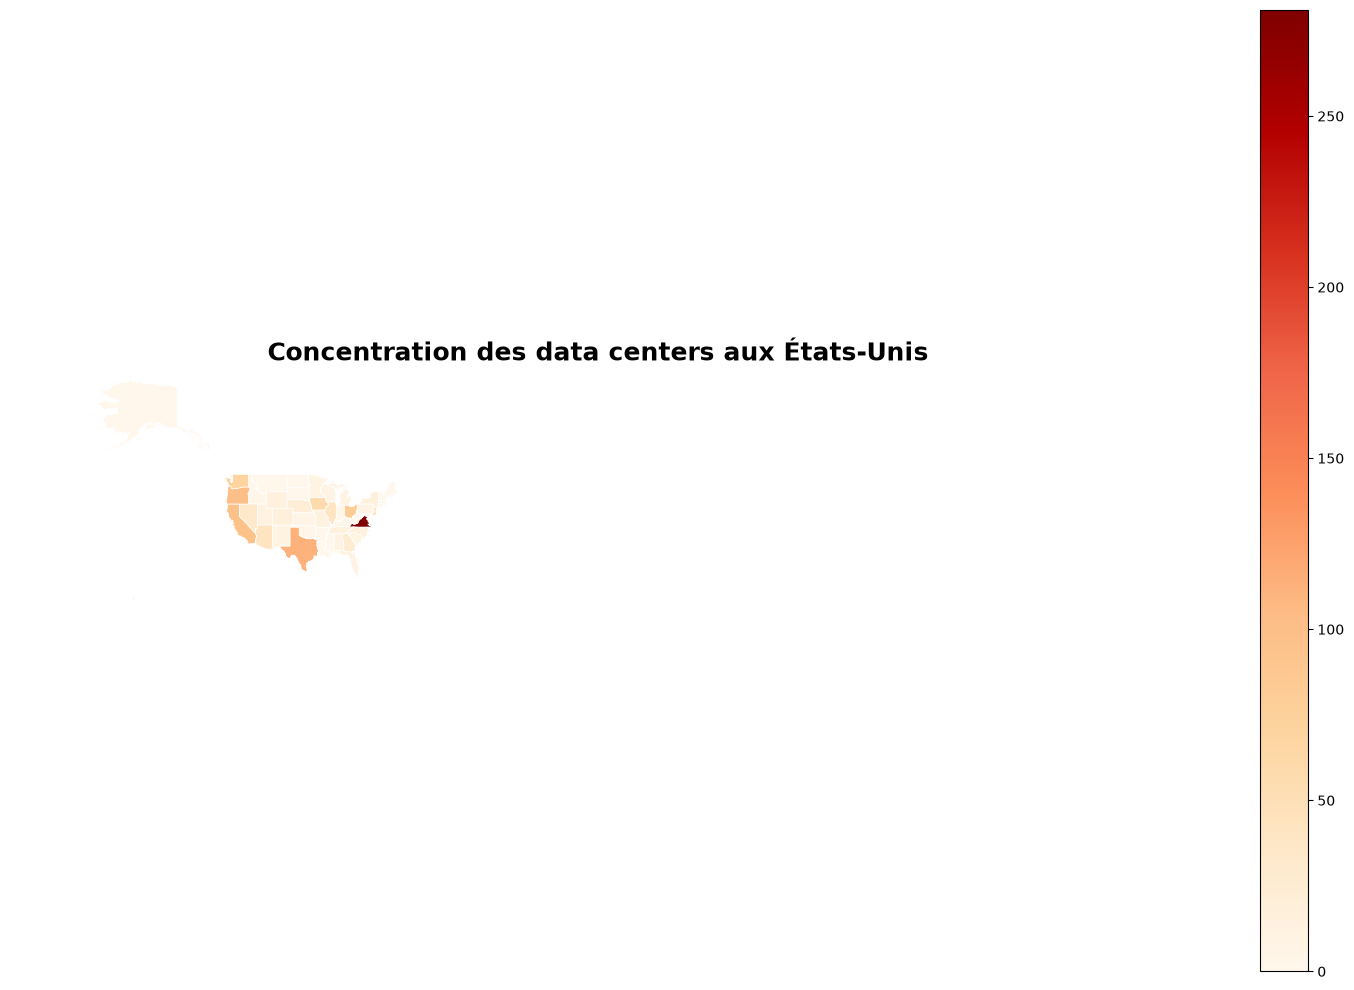

In [18]:

fig, ax = plt.subplots(figsize=(15, 10))

states_map.plot(
    column="data_center_count",
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "label": "Aucun record dans le dataset"
    }
)

ax.set_title(
    "Concentration des data centers aux États-Unis",
    fontsize=18,
    fontweight="bold"
)

ax.axis("off")

plt.tight_layout()
plt.show()



## 13. 🗺️ Carte des bâtiments avec Contextily

Contextily permet d'ajouter un fond cartographique réel.

On transforme d'abord les coordonnées en **Web Mercator — EPSG:3857**, projection utilisée par la plupart des fonds de carte web.


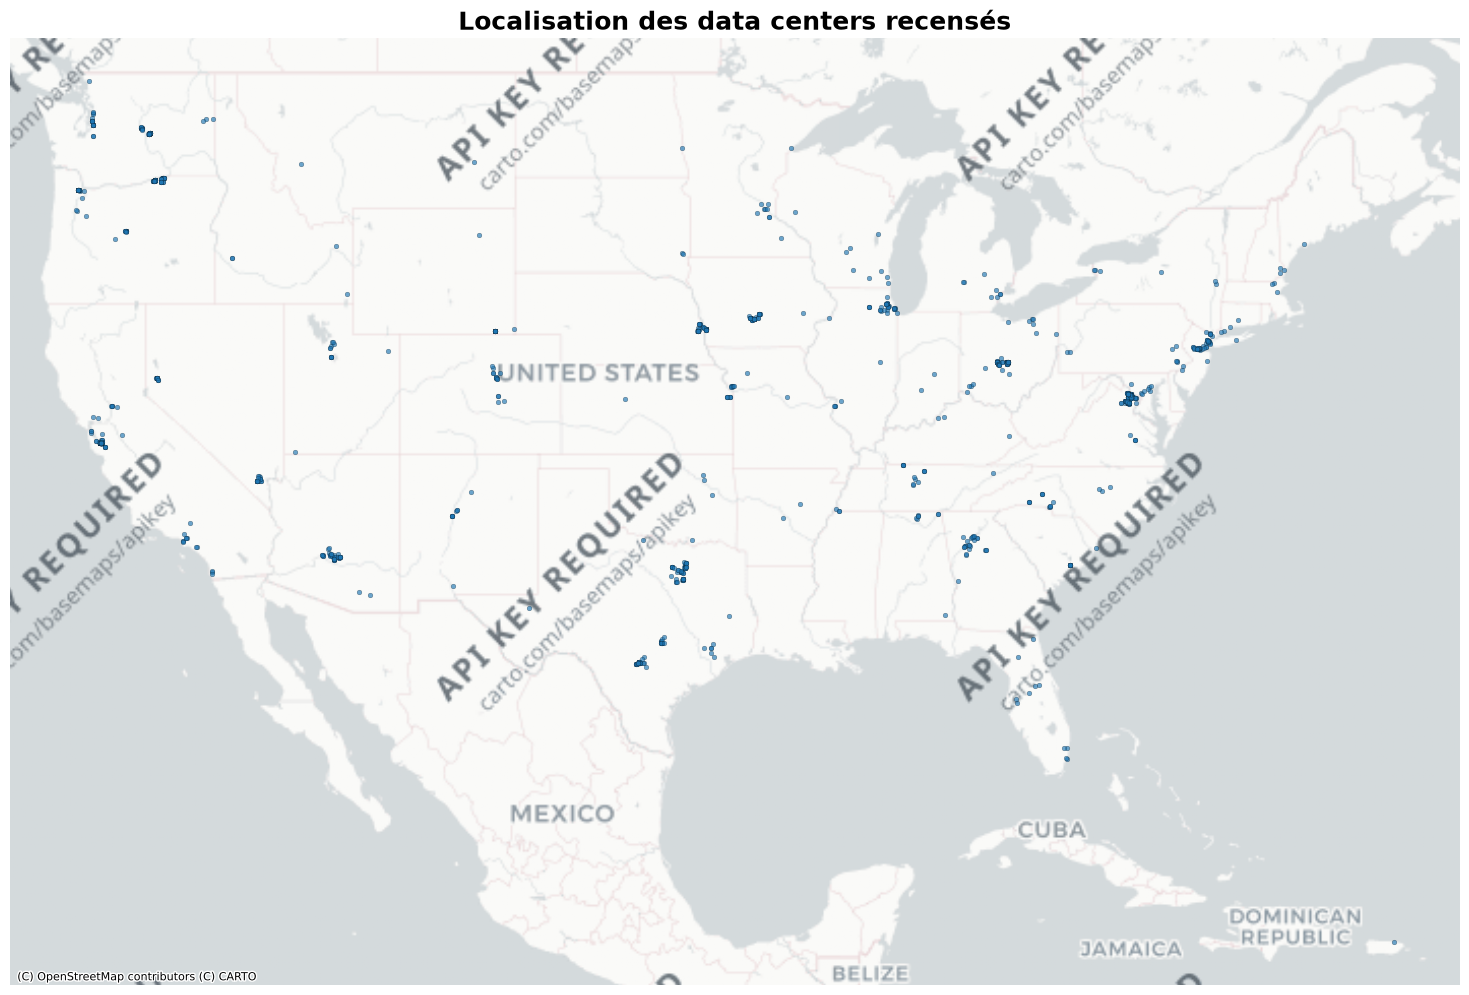

In [19]:

gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(15, 10))

gdf_web.plot(
    ax=ax,
    markersize=12,
    alpha=0.65,
    edgecolor="black",
    linewidth=0.2
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title(
    "Localisation des data centers recensés",
    fontsize=18,
    fontweight="bold"
)

ax.axis("off")

plt.tight_layout()
plt.show()



## 14. Carte Contextily avec taille des points

La taille des points représente ici la **surface du bâtiment**, si la colonne de surface est disponible.

Comme les valeurs de surface peuvent être absentes ou très dispersées, on utilise une transformation logarithmique.


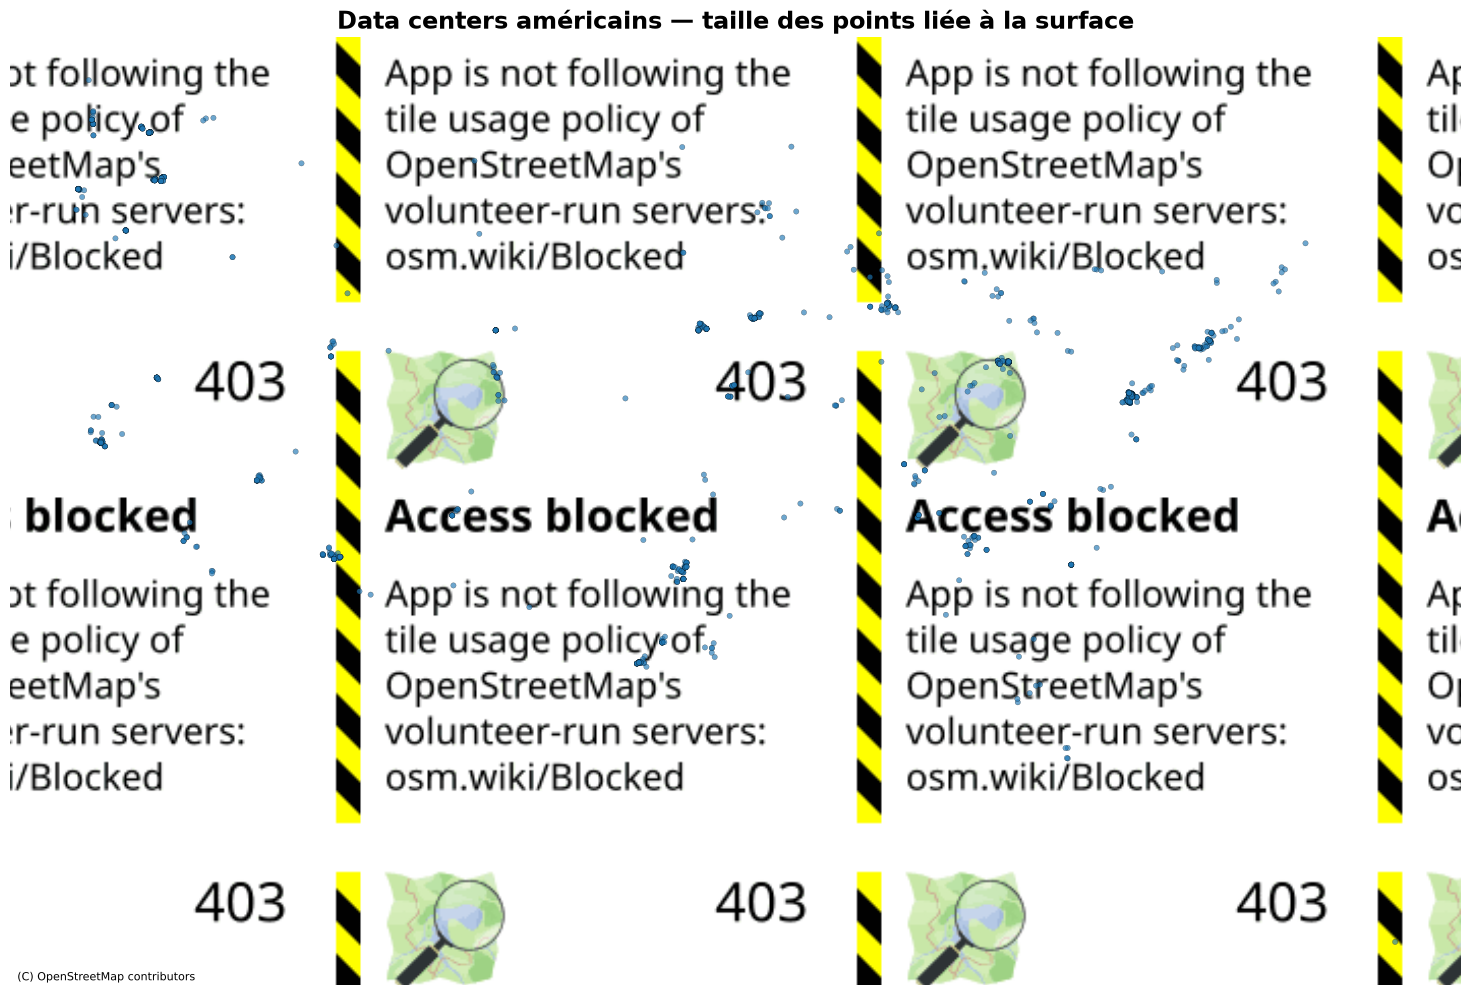

Colonne de surface utilisée : None


In [20]:

# Recherche robuste de la colonne de surface
area_candidates = [
    c for c in gdf.columns
    if "square" in c or "feet" in c or "area" in c
]

if area_candidates:
    area_col = area_candidates[0]
    gdf_web["size_value"] = pd.to_numeric(
        gdf_web[area_col],
        errors="coerce"
    ).fillna(0)

    gdf_web["point_size"] = (
        np.log1p(gdf_web["size_value"]) * 3
    ).clip(lower=5, upper=180)
else:
    area_col = None
    gdf_web["point_size"] = 15

fig, ax = plt.subplots(figsize=(15, 10))

gdf_web.plot(
    ax=ax,
    markersize=gdf_web["point_size"],
    alpha=0.65,
    edgecolor="black",
    linewidth=0.2
)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

ax.set_title(
    "Data centers américains — taille des points liée à la surface",
    fontsize=17,
    fontweight="bold"
)

ax.axis("off")
plt.tight_layout()
plt.show()

print("Colonne de surface utilisée :", area_col)



## 15. Analyse des opérateurs

On regarde maintenant quels opérateurs apparaissent le plus souvent dans le dataset.


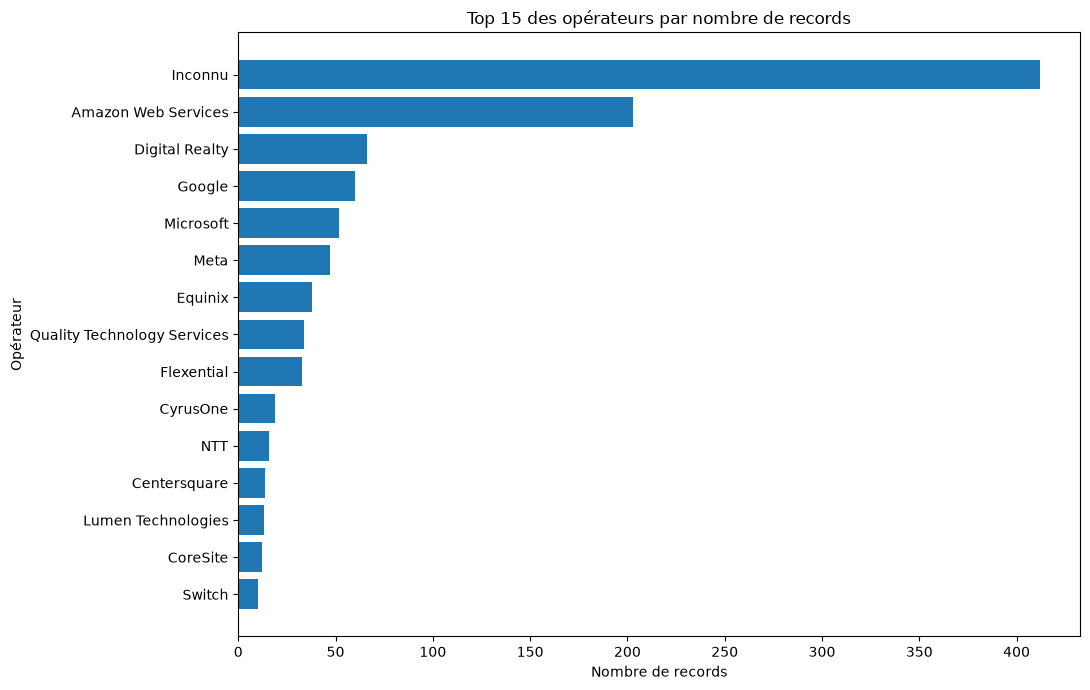

,count
operator,
Switch,10
CoreSite,12
Lumen Technologies,13
Centersquare,14
NTT,16
CyrusOne,19
Flexential,33
Quality Technology Services,34
Equinix,38


In [21]:

if "operator" in gdf.columns:
    operator_counts = (
        gdf["operator"]
        .fillna("Inconnu")
        .replace("", "Inconnu")
        .value_counts()
        .head(15)
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(11, 7))

    ax.barh(
        operator_counts.index,
        operator_counts.values
    )

    ax.set_title("Top 15 des opérateurs par nombre de records")
    ax.set_xlabel("Nombre de records")
    ax.set_ylabel("Opérateur")

    plt.tight_layout()
    plt.show()

    display(operator_counts.to_frame("count"))
else:
    print("La colonne operator n'est pas disponible.")



# 16. 🌐 Carte interactive avec Plotly

Plotly permet de passer de la carte analytique statique à une visualisation exploratoire :

- zoom ;
- déplacement ;
- survol ;
- informations détaillées ;
- filtrage possible ensuite.



In [27]:
!pip install nbformat

In [28]:
import sys
import nbformat


plot_df = gdf.copy()

# Colonnes de tooltip
hover_cols = [
    c for c in [
        "state",
        "county",
        "operator",
        "name",
        "latitude",
        "longitude"
    ]
    if c in plot_df.columns
]

fig = px.scatter_geo(
    plot_df,
    lat="latitude",
    lon="longitude",
    scope="usa",
    projection="albers usa",
    hover_name="name" if "name" in plot_df.columns else None,
    hover_data=hover_cols,
    title="Data centers américains — carte interactive"
)

fig.update_traces(
    marker=dict(
        size=6,
        opacity=0.65
    )
)

fig.update_layout(
    height=750,
    margin=dict(l=20, r=20, t=70, b=20)
)
# Open the interactive Plotly figure in the default web browser
fig.show(renderer="browser")



## 17. Carte Plotly agrégée par État

Pour une restitution métier, il est également utile d'avoir une vue synthétique.


In [29]:

state_plot = states_map[
    ["NAME", "STUSPS", "data_center_count", "geometry"]
].copy()

# Centroïdes pour positionner les labels éventuels
state_plot["centroid"] = state_plot.geometry.to_crs(5070).centroid.to_crs(4326)

state_plot["latitude"] = state_plot["centroid"].y
state_plot["longitude"] = state_plot["centroid"].x

fig = px.choropleth(
    state_plot,
    locations="STUSPS",
    locationmode="USA-states",
    color="data_center_count",
    scope="usa",
    hover_name="NAME",
    hover_data={
        "STUSPS": True,
        "data_center_count": True,
        "latitude": False,
        "longitude": False
    },
    color_continuous_scale="OrRd",
    title="Nombre de data centers recensés par État"
)

fig.update_layout(
    height=700,
    geo=dict(
        showlakes=True,
        lakecolor="white"
    )
)

fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed


# 18. KPI du projet

On calcule quelques indicateurs simples pour la restitution.


In [ ]:

total_records = len(gdf)
total_states = gdf["state"].nunique()
top_state = state_counts.iloc[0]
top_5_share = state_counts.head(5)["share_pct"].sum()

print(f"Nombre de records analysés : {total_records:,}")
print(f"Nombre d'États avec au moins un record : {total_states}")
print(
    f"État n°1 : {top_state['state']} "
    f"({int(top_state['data_center_count'])} records)"
)
print(f"Part du Top 5 : {top_5_share:.1f}%")



# 19. Conclusions automatiques

Les chiffres ci-dessous sont générés directement à partir du dataset chargé. Ils ne sont donc pas écrits manuellement dans le notebook.


In [ ]:

top3 = state_counts.head(3)

print("### Principaux constats")
print()

for i, row in top3.reset_index(drop=True).iterrows():
    print(
        f"{i+1}. {row['state']} : "
        f"{int(row['data_center_count'])} records "
        f"({row['share_pct']:.1f}% du total)"
    )

print()
print(
    f"Les 5 premiers États représentent "
    f"{top_5_share:.1f}% des records du dataset."
)

print()
print(
    "Interprétation : la distribution géographique est fortement "
    "concentrée dans certains marchés américains. Cette concentration "
    "peut être étudiée avec d'autres variables comme l'énergie disponible, "
    "le réseau électrique, la fibre, l'eau ou les projets en construction."
)



# 20. 🚀 Extensions pour transformer ce notebook en vrai projet portfolio

## Niveau 1 — Data Analysis

Ajouter :

- évolution du nombre de projets par année ;
- répartition par statut ;
- top opérateurs ;
- surface totale par État ;
- part du Top 5 / Top 10 ;
- comparaison entre nombre de sites et surface.

## Niveau 2 — Géospatial

Ajouter :

- distance aux grandes villes ;
- distance aux lignes électriques ;
- proximité des réseaux fibre ;
- densité de data centers par km² ;
- clustering avec `DBSCAN`.

## Niveau 3 — Business

Construire une problématique :

> **Quels territoires américains sont les plus attractifs pour le développement de nouveaux data centers ?**

Créer alors un score à partir de :

```text
Attractivité =
    proximité réseau électrique
  + disponibilité énergétique
  + fibre
  + concentration actuelle
  + projets futurs
  + disponibilité foncière
```

## Niveau 4 — Dashboard

Utiliser :

- Plotly ;
- Streamlit ou Power BI ;
- filtres par État ;
- filtres par opérateur ;
- statut ;
- capacité ;
- année.

---

# Sources et limites

**Source principale :** PNNL IM3 Open Source Data Center Atlas, distribué sous ODbL et basé notamment sur des données OpenStreetMap.

**Limite importante :** l'absence d'un data center dans le dataset ne signifie pas qu'il n'existe pas. La couverture dépend notamment de la cartographie OpenStreetMap et de la validation des données.

Pour un portfolio, cette limite doit apparaître explicitement dans le README : elle montre que tu sais distinguer **donnée observée** et **réalité exhaustive**.
